# NBA Live Win Probability — Baseline and Q4 Bonus Model

This notebook builds two clean live win-probability models:

1. **Baseline model** using score, time, possession, period, and pregame/team-strength prior.
2. **Improved model** adding NBA-specific fourth-quarter bonus indicators.

The goal is to keep the modeling workflow simple, reproducible, and easy to evaluate.

## 1. Setup

Update `DATA_PATH` if your CSV is stored somewhere else. The notebook expects the slim modeling dataset created from the play-by-play pipeline.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve


DATA_PATH = Path("nba_win_prob_slim.csv")
TEST_SIZE = 0.20
RANDOM_STATE = 42

## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)

df["game_id"] = df["game_id"].astype(str).str.zfill(10)

if "game_date" in df.columns:
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")

print(f"Shape: {df.shape}")
print(f"Games: {df['game_id'].nunique():,}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Date range: {df['game_date'].min()} to {df['game_date'].max()}")

display(df.head())

Shape: (1661962, 66)
Games: 3,855
Memory: 929.8 MB
Date range: 2023-10-24 00:00:00 to 2026-04-12 00:00:00


,game_id,is_playoffs,home_team_won,period,is_overtime,seconds_remaining,score_diff,momentum_5,momentum_10,home_possession,...,away_b2b,home_3in4,away_3in4,diff_net_rtg_last10,diff_net_rtg_last20,diff_net_rtg_lastseason,diff_off_rtg_last10,diff_def_rtg_last10,day_of_week,is_weekend
0,0022300001,0,1,1,0,2861.0,2,NaN,NaN,1,...,0,1,1,-2.018877,-2.018877,-2.018877,7.920886,9.939763,4,1
1,0022300001,0,1,1,0,2843.0,2,NaN,NaN,0,...,0,1,1,-2.018877,-2.018877,-2.018877,7.920886,9.939763,4,1
2,0022300001,0,1,1,0,2840.0,2,NaN,NaN,1,...,0,1,1,-2.018877,-2.018877,-2.018877,7.920886,9.939763,4,1
3,0022300001,0,1,1,0,2835.0,2,NaN,NaN,1,...,0,1,1,-2.018877,-2.018877,-2.018877,7.920886,9.939763,4,1
4,0022300001,0,1,1,0,2832.0,2,NaN,NaN,1,...,0,1,1,-2.018877,-2.018877,-2.018877,7.920886,9.939763,4,1


## 3. Feature Engineering

The baseline features are intentionally simple and interpretable. They capture the main live win-probability drivers: score differential, time remaining, possession, and team strength.

The improved model adds fourth-quarter bonus indicators. Since `home_fouls` and `away_fouls` appear to be cumulative game totals, the Q4 foul features subtract each team's cumulative foul count at the start of the fourth quarter.

In [3]:
def add_baseline_features(data: pd.DataFrame) -> pd.DataFrame:
    """Add score/time features used by the baseline model."""
    out = data.copy()

    out["abs_score_diff"] = out["score_diff"].abs()
    out["minutes_remaining"] = out["seconds_remaining"] / 60

    # These interactions help logistic regression model the nonlinear value
    # of a lead as the game gets closer to the end.
    out["score_x_time"] = out["score_diff"] * out["minutes_remaining"]
    out["abs_score_x_time"] = out["abs_score_diff"] * out["minutes_remaining"]
    out["score_per_minute_remaining"] = out["score_diff"] / (out["minutes_remaining"] + 0.5)

    return out


def add_q4_bonus_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create Q4-only bonus indicators from cumulative foul totals."""
    out = data.copy()

    out = out.sort_values(
        ["game_id", "period", "seconds_remaining"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    out["is_4q"] = (out["period"] == 4).astype(int)
    out["is_late_4q"] = ((out["period"] == 4) & (out["seconds_remaining"] <= 300)).astype(int)
    out["is_clutch_4q"] = (
        (out["period"] == 4) &
        (out["seconds_remaining"] <= 300) &
        (out["score_diff"].abs() <= 5)
    ).astype(int)

    # Approximate foul counts at the start of the fourth quarter.
    q4_start_fouls = (
        out[out["period"] == 4]
        .groupby("game_id")[["home_fouls", "away_fouls"]]
        .first()
        .rename(columns={
            "home_fouls": "home_fouls_start_q4",
            "away_fouls": "away_fouls_start_q4",
        })
    )

    out = out.merge(q4_start_fouls, on="game_id", how="left")

    # Convert cumulative game fouls into fourth-quarter-only foul counts.
    out["home_fouls_q4"] = np.where(
        out["period"] == 4,
        out["home_fouls"] - out["home_fouls_start_q4"],
        0
    )

    out["away_fouls_q4"] = np.where(
        out["period"] == 4,
        out["away_fouls"] - out["away_fouls_start_q4"],
        0
    )

    out["home_fouls_q4"] = out["home_fouls_q4"].fillna(0).clip(lower=0)
    out["away_fouls_q4"] = out["away_fouls_q4"].fillna(0).clip(lower=0)

    # NBA penalty/bonus logic:
    # If away has 5+ Q4 team fouls, home offense is in the bonus.
    # If home has 5+ Q4 team fouls, away offense is in the bonus.
    out["home_team_in_penalty_q4"] = ((out["period"] == 4) & (out["home_fouls_q4"] >= 5)).astype(int)
    out["away_team_in_penalty_q4"] = ((out["period"] == 4) & (out["away_fouls_q4"] >= 5)).astype(int)

    out["home_offense_bonus_q4"] = out["away_team_in_penalty_q4"]
    out["away_offense_bonus_q4"] = out["home_team_in_penalty_q4"]

    # Home perspective:
    # +1 means home has the bonus advantage.
    # -1 means away has the bonus advantage.
    #  0 means both/neither.
    out["home_bonus_advantage_q4"] = (
        out["home_offense_bonus_q4"] - out["away_offense_bonus_q4"]
    )

    # Possession-aware bonus flag.
    out["current_offense_has_bonus_q4"] = np.where(
        out["home_possession"] == 1,
        out["home_offense_bonus_q4"],
        out["away_offense_bonus_q4"],
    )

    return out


df = add_baseline_features(df)
df = add_q4_bonus_features(df)

display(
    df.loc[df["period"] == 4, [
        "game_id", "period", "seconds_remaining",
        "home_fouls", "away_fouls",
        "home_fouls_q4", "away_fouls_q4",
        "home_offense_bonus_q4", "away_offense_bonus_q4",
        "home_bonus_advantage_q4", "current_offense_has_bonus_q4"
    ]].head(10)
)

,game_id,period,seconds_remaining,home_fouls,away_fouls,home_fouls_q4,away_fouls_q4,home_offense_bonus_q4,away_offense_bonus_q4,home_bonus_advantage_q4,current_offense_has_bonus_q4
318,0022300001,4,699.0,2.0,1.0,0.0,0.0,0,0,0,0
319,0022300001,4,699.0,2.0,1.0,0.0,0.0,0,0,0,0
320,0022300001,4,697.0,2.0,1.0,0.0,0.0,0,0,0,0
321,0022300001,4,696.0,2.0,1.0,0.0,0.0,0,0,0,0
322,0022300001,4,675.0,2.0,1.0,0.0,0.0,0,0,0,0
323,0022300001,4,666.0,2.0,1.0,0.0,0.0,0,0,0,0
324,0022300001,4,660.0,2.0,1.0,0.0,0.0,0,0,0,0
325,0022300001,4,660.0,2.0,1.0,0.0,0.0,0,0,0,0
326,0022300001,4,651.0,2.0,1.0,0.0,0.0,0,0,0,0
327,0022300001,4,638.0,2.0,1.0,0.0,0.0,0,0,0,0


## 4. Feature Sets

The improved model keeps the added feature group compact. This matters because sparse context indicators can easily add noise if the model includes too many overlapping versions.

In [13]:
baseline_features = [
    "period",
    "is_overtime",
    "seconds_remaining",
    "minutes_remaining",
    "score_diff",
    "abs_score_diff",
    "home_possession",
    "score_x_time",
    "abs_score_x_time",
    "score_per_minute_remaining",
    "diff_net_rtg_lastseason",
]

q4_bonus_medium_features = [
    "home_offense_bonus_q4",
    "away_offense_bonus_q4",
    "current_offense_has_bonus_q4",
]

feature_sets = {
    "baseline": baseline_features,
    "baseline_plus_q4_bonus_medium": baseline_features + q4_bonus_medium_features,
}

required_columns = sorted(set(["game_id", "game_date", "home_team_won"] + sum(feature_sets.values(), [])))
missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Feature sets:")
for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")

Feature sets:
baseline: 11 features
baseline_plus_q4_bonus_medium: 14 features


## 5. Temporal Train/Test Split

The split is by game, not by row, so rows from the same game do not appear in both train and test. The split is also chronological to better approximate future-game prediction.

In [14]:
def get_temporal_train_test_games(data: pd.DataFrame, test_size: float = 0.20):
    games = (
        data[["game_id", "game_date"]]
        .drop_duplicates("game_id")
        .dropna(subset=["game_date"])
        .sort_values("game_date")
        .reset_index(drop=True)
    )

    cutoff_idx = int(len(games) * (1 - test_size))

    train_games = games.iloc[:cutoff_idx]["game_id"]
    test_games = games.iloc[cutoff_idx:]["game_id"]

    print("Train date range:", games.iloc[:cutoff_idx]["game_date"].min(), "to", games.iloc[:cutoff_idx]["game_date"].max())
    print("Test date range:", games.iloc[cutoff_idx:]["game_date"].min(), "to", games.iloc[cutoff_idx:]["game_date"].max())
    print(f"Train games: {train_games.nunique():,}")
    print(f"Test games: {test_games.nunique():,}")

    return train_games, test_games


train_games, test_games = get_temporal_train_test_games(df, test_size=TEST_SIZE)

Train date range: 2023-10-24 00:00:00 to 2025-12-27 00:00:00
Test date range: 2025-12-27 00:00:00 to 2026-04-12 00:00:00
Train games: 3,084
Test games: 771


## 6. Model Training and Evaluation Helpers

Both models use regularized logistic regression. This keeps the model interpretable and stable for probability estimation.

In [15]:
def train_and_predict_feature_set(
    data: pd.DataFrame,
    features: list[str],
    train_games: pd.Series,
    test_games: pd.Series,
    C: float = 1.0,
    target_col: str = "home_team_won",
):
    features = [c for c in features if c in data.columns]

    keep_cols = [
        "game_id", "game_date", target_col,
        "period", "seconds_remaining", "score_diff",
    ] + features

    keep_cols = list(dict.fromkeys(keep_cols))

    model_df = data[keep_cols].copy()
    model_df = model_df.dropna(subset=[target_col])

    train_mask = model_df["game_id"].isin(train_games)
    test_mask = model_df["game_id"].isin(test_games)

    X_train = model_df.loc[train_mask, features].copy()
    y_train = model_df.loc[train_mask, target_col].astype(int)

    X_test = model_df.loc[test_mask, features].copy()
    y_test = model_df.loc[test_mask, target_col].astype(int)

    # Use train medians only to avoid leakage.
    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            C=C,
            penalty="l2",
            solver="lbfgs",
            max_iter=3000,
            random_state=RANDOM_STATE,
        )),
    ])

    model.fit(X_train, y_train)

    pred = model.predict_proba(X_test)[:, 1]

    results = model_df.loc[test_mask].copy()
    results["actual"] = y_test.values
    results["pred_home_win_prob"] = pred

    return model, results


def score_results(results: pd.DataFrame, subset_name: str = "all") -> dict:
    y_true = results["actual"]
    y_pred = results["pred_home_win_prob"]

    return {
        "subset": subset_name,
        "rows": len(results),
        "games": results["game_id"].nunique(),
        "log_loss": log_loss(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_pred) if y_true.nunique() > 1 else np.nan,
        "actual_home_win_rate": y_true.mean(),
        "avg_pred_home_win_prob": y_pred.mean(),
    }

## 7. Train Baseline and Improved Models

In [16]:
models = {}
results_by_model = {}
overall_rows = []

for model_name, features in feature_sets.items():
    print(f"Training {model_name}...")

    model, results = train_and_predict_feature_set(
        data=df,
        features=features,
        train_games=train_games,
        test_games=test_games,
        C=1.0,
    )

    models[model_name] = model
    results_by_model[model_name] = results

    metrics = score_results(results, subset_name="all")
    metrics["feature_set"] = model_name
    metrics["num_features"] = len(features)
    overall_rows.append(metrics)

overall_metrics = pd.DataFrame(overall_rows).sort_values("log_loss")

display(
    overall_metrics[
        [
            "feature_set", "num_features", "rows", "games",
            "log_loss", "brier_score", "roc_auc",
            "actual_home_win_rate", "avg_pred_home_win_prob",
        ]
    ]
)

Training baseline...
Training baseline_plus_q4_bonus_medium...


,feature_set,num_features,rows,games,log_loss,brier_score,roc_auc,actual_home_win_rate,avg_pred_home_win_prob
1,baseline_plus_q4_bonus_medium,14,334468,771,0.423523,0.140340,0.880877,0.555949,0.548205
0,baseline,11,334468,771,0.423562,0.140353,0.880853,0.555949,0.548205


## 8. Evaluate the Models Where Q4 Bonus Should Matter

The bonus indicators should matter most in fourth-quarter, late-game, close-game, and clutch-game states.

In [18]:
subset_rows = []

for model_name, results in results_by_model.items():
    subsets = {
        "all": results,
        "q4_only": results[results["period"] == 4],
        "late_q4": results[
            (results["period"] == 4) &
            (results["seconds_remaining"] <= 300)
        ],
        "close_q4": results[
            (results["period"] == 4) &
            (results["score_diff"].abs() <= 10)
        ],
        "clutch_q4": results[
            (results["period"] == 4) &
            (results["seconds_remaining"] <= 300) &
            (results["score_diff"].abs() <= 5)
        ],
    }

    for subset_name, subset in subsets.items():
        if len(subset) < 100:
            continue

        metrics = score_results(subset, subset_name=subset_name)
        metrics["feature_set"] = model_name
        metrics["num_features"] = len(feature_sets[model_name])
        subset_rows.append(metrics)

subset_metrics = pd.DataFrame(subset_rows)

display(
    subset_metrics[
        [
            "feature_set", "subset", "num_features", "rows", "games",
            "log_loss", "brier_score", "roc_auc",
            "actual_home_win_rate", "avg_pred_home_win_prob",
        ]
    ].sort_values(["subset", "log_loss"])
)

,feature_set,subset,num_features,rows,games,log_loss,brier_score,roc_auc,actual_home_win_rate,avg_pred_home_win_prob
5,baseline_plus_q4_bonus_medium,all,14,334468,771,0.423523,0.140340,0.880877,0.555949,0.548205
0,baseline,all,11,334468,771,0.423562,0.140353,0.880853,0.555949,0.548205
8,baseline_plus_q4_bonus_medium,close_q4,14,39528,512,0.420909,0.137425,0.886260,0.540427,0.519011
3,baseline,close_q4,11,39528,512,0.421266,0.137546,0.886066,0.540427,0.518945
9,baseline_plus_q4_bonus_medium,clutch_q4,14,10515,321,0.450061,0.147935,0.867492,0.554351,0.522859
4,baseline,clutch_q4,11,10515,321,0.451362,0.148369,0.866803,0.554351,0.522475
7,baseline_plus_q4_bonus_medium,late_q4,14,37039,771,0.154875,0.048602,0.985435,0.556899,0.547672
2,baseline,late_q4,11,37039,771,0.155242,0.048725,0.985359,0.556899,0.547560
6,baseline_plus_q4_bonus_medium,q4_only,14,83640,771,0.220782,0.069825,0.970030,0.556074,0.546324
1,baseline,q4_only,11,83640,771,0.220950,0.069882,0.969979,0.556074,0.546293


## 9. Calibration Curves

For a win-probability model, calibration is as important as ranking. A well-calibrated model's predicted probabilities should match empirical win rates.

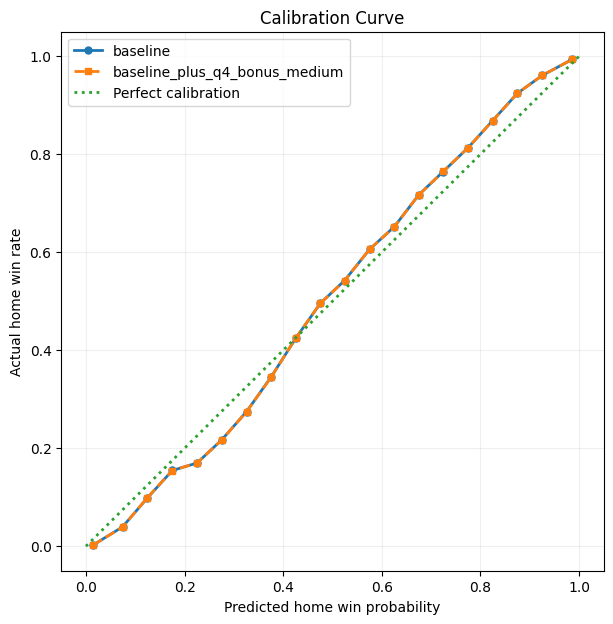

In [22]:
plt.figure(figsize=(7, 7))

line_styles = {
    "baseline": "-",
    "baseline_plus_q4_bonus_medium": "--",
}

markers = {
    "baseline": "o",
    "baseline_plus_q4_bonus_medium": "s",
}

for model_name, results in results_by_model.items():
    prob_true, prob_pred = calibration_curve(
        results["actual"],
        results["pred_home_win_prob"],
        n_bins=20,
        strategy="uniform",
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker=markers.get(model_name, "o"),
        linestyle=line_styles.get(model_name, "-"),
        linewidth=2,
        markersize=5,
        label=model_name,
    )

plt.plot([0, 1], [0, 1], linestyle=":", linewidth=2, label="Perfect calibration")
plt.xlabel("Predicted home win probability")
plt.ylabel("Actual home win rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

The baseline and improved model curves nearly overlap because the Q4 bonus features only make small, localized adjustments. The improvement appears mainly in Q4 subsets. 

## 10. Coefficient Review

The coefficients below are standardized because the model uses `StandardScaler`. They are useful for checking whether feature directions make basketball sense.

In [20]:
def coefficient_table(model: Pipeline, features: list[str]) -> pd.DataFrame:
    logreg = model.named_steps["logreg"]
    coefs = logreg.coef_[0]

    return (
        pd.DataFrame({
            "feature": features,
            "standardized_coef": coefs,
            "abs_coef": np.abs(coefs),
        })
        .sort_values("abs_coef", ascending=False)
        .reset_index(drop=True)
    )


for model_name, model in models.items():
    print(f"\n{model_name}")
    coef_df = coefficient_table(model, feature_sets[model_name])
    display(coef_df)


baseline


,feature,standardized_coef,abs_coef
0,score_per_minute_remaining,2.045359,2.045359
1,score_diff,1.884258,1.884258
2,score_x_time,-0.608146,0.608146
3,diff_net_rtg_lastseason,0.547548,0.547548
4,abs_score_diff,0.066125,0.066125
5,abs_score_x_time,-0.033224,0.033224
6,is_overtime,0.028661,0.028661
7,period,-0.022863,0.022863
8,seconds_remaining,0.010936,0.010936
9,minutes_remaining,0.010936,0.010936



baseline_plus_q4_bonus_medium


,feature,standardized_coef,abs_coef
0,score_per_minute_remaining,2.045696,2.045696
1,score_diff,1.884381,1.884381
2,score_x_time,-0.608244,0.608244
3,diff_net_rtg_lastseason,0.547508,0.547508
4,abs_score_diff,0.066248,0.066248
5,abs_score_x_time,-0.033234,0.033234
6,is_overtime,0.028711,0.028711
7,period,-0.022872,0.022872
8,seconds_remaining,0.011061,0.011061
9,minutes_remaining,0.011061,0.011061


## 11. Save Test Predictions

This saves row-level predictions from the improved model for later error analysis, charts, or app prototypes.

In [21]:
best_model_name = "baseline_plus_q4_bonus_medium"
predictions_path = Path("model_predictions_baseline_plus_q4_bonus.csv")

prediction_cols = [
    "game_id", "game_date", "period", "seconds_remaining", "score_diff",
    "actual", "pred_home_win_prob",
]

predictions = results_by_model[best_model_name][prediction_cols].copy()
predictions.to_csv(predictions_path, index=False)

print(f"Saved predictions to: {predictions_path}")
display(predictions.head())

Saved predictions to: model_predictions_baseline_plus_q4_bonus.csv


,game_id,game_date,period,seconds_remaining,score_diff,actual,pred_home_win_prob
1059637,0022500014,2026-01-19,1,2863.0,0,0,0.513547
1059638,0022500014,2026-01-19,1,2860.0,0,0,0.514553
1059639,0022500014,2026-01-19,1,2854.0,-2,0,0.489286
1059640,0022500014,2026-01-19,1,2847.0,0,0,0.513441
1059641,0022500014,2026-01-19,1,2833.0,-2,0,0.488678


## Summary

The baseline model is already strong because score, time, possession, and team-strength prior explain most of live win probability.

The improved model adds compact fourth-quarter bonus indicators. This produced the clearest gain in fourth-quarter and clutch subsets, which is where bonus context should matter most. Momentum and other in game features actually did not matter, and tended to overfit, but perhaps using indicators to place them only in relevant contexts will demonstrate an improvement as it did with the bonus. 

This notebook establishes a strong interpretable baseline. Future work will focus on deriving more useful contextual features and improving pregame team-strength estimates, including betting-market implied probabilities, Elo-style ratings, and player availability. Eventually tree-based models such as XGBoost will be built using the final feature set.